<a href="https://colab.research.google.com/github/amelyssaeu-ab/bio-dkm/blob/main/tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 05 - Semana 3
### Efeito da Benzilaminopurina (BAP) na indução de brotos e folhas de grumixama (*Eugenia* sp.) cultivada *in vitro*

##### Drielly Mathias Albertti - nº 16831084
##### Kawana Ganeo de Carvalho - nº 14669691
##### Melyssa Ponce Lopes - nº 16831017


##1. Há observações atípicas dos dados? Qual o valor mínimo e máximo das variáveis? O que elas representam?

####Valores atípicos:  
Em Brotos, 1 mg/L é o único tratamento com pontos marcados como valores
atípicos, mostrando vários pontos marcados como "outlier" pelo critério estatístico (1,5×IQR), mesmo assim ele apresenta baixa dispersão central (Q1 e Q3 muito próximos, já que os dados são contagens pequenas).  

Em Folhas, aparecem valores atípicos pontuais em 2 mg/L (valor 32) e 3 mg/L
(valor 46), nos dois casos, os explantes produziram muito mais folhas do que o típico do seu tratamento.

####Valores mínimos e máximos:
Brotos: mínimo = 0 e máximo = 6 (por explante, no conjunto todo). O mínimo
indica explantes que não formaram brotos; o máximo indica o explante com maior
capacidade de brotação observada.

Folhas: mínimo = 0 e máximo = 46. O mínimo indica ausência total de folhas
(geralmente associado a ausência de brotos também); o máximo é o explante com
maior desenvolvimento foliar do experimento.

##2. Determine os 2º e 3° quartis para o número de brotos e folhas e o que eles representam
Considerando o conjunto completo (120 explantes):   
Brotos → Q2 (mediana) = 2 e Q3 = 2;  
Folhas → Q2 = 10 e Q3 = 18.  

Isso significa que metade dos explantes produziu até 2 brotos e até 10 folhas, e 75% produziu até 2 brotos e até 18 folhas, ou seja, a distribuição é concentrada em valores baixos, com uma "cauda" de poucos explantes com produção bem maior.  

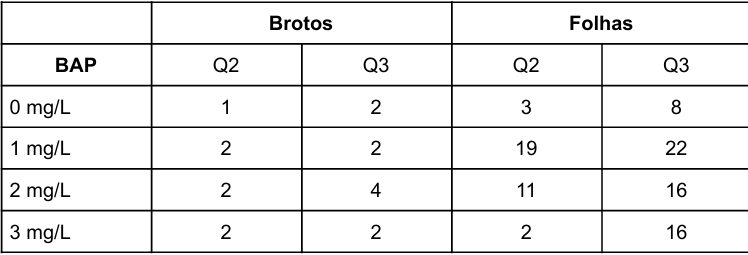

Para o número de brotos, observou-se que os tratamentos com 1 mg/L e 3 mg/L de BAP apresentaram Q2 e Q3 iguais a 2, indicando maior concentração dos dados em torno desse valor.
Já o tratamento com 2 mg/L apresentou Q2 = 2 e Q3 = 4, indicando maior dispersão dos valores acima da mediana.

Para o número de folhas, o tratamento com 1 mg/L apresentou Q2 = 19 e Q3 = 22, indicando uma maior produção típica de folhas e relativa concentração dos
dados próximos a valores elevados. Por outro lado, o tratamento com 3 mg/L
apresentou Q2 = 2 e Q3 = 16, mostrando grande dispersão dos dados, pois
enquanto menos da metade dos explantes apresentou poucas folhas, uma parte dos
explantes apresentou valores consideravelmente maiores.

##3. Qual é o número médio de brotos e folhas por explante em cada concentração de BAP?

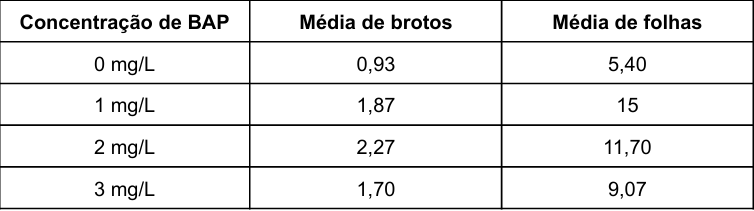

##4.  Quais tratamentos apresentam maior variabilidade aparente?

Em Brotos, o controle tem o maior CV (88,7%), seguido do tratamento 3,0 mg/L
(86,2%), ou seja, variam proporcionalmente mais, mesmo com médias baixas.

Em Folhas, o tratamento 3,0 mg/L tem o maior CV (122,7%) e também a maior
amplitude (0–46), mostrando o comportamento mais heterogêneo de todos.  

Para os brotos, os tratamentos 2 e 3 apresentam maior variabilidade aparente,
principalmente pelos maiores desvios-padrão. Já para as folhas, os tratamentos 1 e 3 apresentam maior variabilidade absoluta, com DP de aproximadamente 11,13
folhas. Portanto, de maneira geral, os tratamentos 2 e 3 são mais variáveis para brotos, enquanto 1 e 3 são mais variáveis para folhas.

##5.  Existe diferença entre o controle e cada uma das doses de BAP?
Sim, há diferença visível nas médias e nas distribuições. Todas as doses de
BAP aumentaram a média de brotos e de folhas em relação ao controle (0,93 brotos / 5,40 folhas). O maior ganho em brotos foi em 2,0 mg/L (2,27) e o maior ganho em folhas foi em 1,0 mg/L (15,00).

##6.  Qual concentração produz maior e menor número de folhas?
Maior média de folhas: 1,0 mg/L (15,00).  
Menor média ocorreu no controle: 0,0 mg/L (5,40).  
Menor média (excluindo o controle): 3,0 mg/L (9,07).

##7.  Existem tratamentos nos quais ocorre muita brotação, mas poucas folhas?
Sim, o tratamento 3,0 mg/L tem a segunda maior média de brotos (1,70) mas a
menor mediana de folhas (2,0) entre as doses de BAP, com metade dos explantes
praticamente sem folhas apesar de terem brotado.

In [ ]:
from google.colab import files

uploaded = files.upload()  # selecione o arquivo Tarefa_Semana3.xlsx
nome_arquivo = list(uploaded.keys())[0]
print(f'Arquivo carregado: {nome_arquivo}')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 2)

# Lê apenas a aba 'Eugenia' — a aba 'Iris' não é usada neste trabalho
df = pd.read_excel(nome_arquivo, sheet_name='Eugenia')

dose_map = {0: 0.0, 1: 1.0, 2: 2.0, 3: 3.0}
df['BAP (mg/L)'] = df['Tratamento'].map(dose_map)

print(f'{len(df)} explantes carregados.')
df.head()

## 8. Amplitude, variância e desvio-padrão de Brotos e Folhas por concentração de BAP

Calculamos, para cada concentração de BAP, a amplitude (máx − mín), a variância amostral e o desvio-padrão do número de brotos e do número de folhas por explante.

In [ ]:
def tabela_dispersao(df, var):
    g = df.groupby('BAP (mg/L)')[var]
    tab = pd.DataFrame({
        'Mínimo': g.min(),
        'Máximo': g.max(),
        'Amplitude': g.max() - g.min(),
        'Variância': g.var(ddof=1).round(2),
        'Desvio-padrão': g.std(ddof=1).round(2)
    })
    return tab

tab_brotos = tabela_dispersao(df, 'Brotos')
tab_folhas = tabela_dispersao(df, 'Folhas')

print('Brotos — amplitude, variância e desvio-padrão por concentração de BAP')
display(tab_brotos)

print('\nFolhas — amplitude, variância e desvio-padrão por concentração de BAP')
display(tab_folhas)

**Leitura:** o tratamento de **3,0 mg/L** apresenta a maior amplitude e a maior variância/desvio-padrão em Folhas, enquanto em Brotos a maior variância aparece em **2,0 mg/L**. Isso indica resposta mais heterogênea dos explantes nessas concentrações.

## 9. Coeficiente de variação (CV) de Brotos e Folhas por concentração de BAP

O CV expressa a dispersão relativa à média: $CV(\%) = \dfrac{\text{desvio-padrão}}{\text{média}} \times 100$.

In [ ]:
def tabela_cv(df, var):
    g = df.groupby('BAP (mg/L)')[var]
    media = g.mean()
    dp = g.std(ddof=1)
    cv = (100 * dp / media).round(1)
    return pd.DataFrame({'Média': media.round(2), 'Desvio-padrão': dp.round(2), 'CV (%)': cv})

cv_brotos = tabela_cv(df, 'Brotos')
cv_folhas = tabela_cv(df, 'Folhas')

# Tabela consolidada de CV (Brotos x Folhas), no mesmo formato usado no trabalho
tabela_cv_final = pd.DataFrame({
    'Brotos': cv_brotos['CV (%)'],
    'Folhas': cv_folhas['CV (%)']
})
tabela_cv_final.index.name = 'BAP (mg/L)'

print('Coeficiente de variação (CV)')
display(tabela_cv_final)

**Leitura:** todos os CVs são altos (>60%), típico de dados de contagem biológica com muitos zeros. O tratamento **3,0 mg/L** tem o maior CV em Folhas (122,7%) e o **controle** tem o maior CV em Brotos (88,7%), mostrando que, proporcionalmente à média, esses grupos são os mais heterogêneos.

## 10. Boxplots de Brotos e Folhas por concentração de BAP

In [ ]:
labels = ['0.0 mg/L\n(Controle)', '1.0 mg/L', '2.0 mg/L', '3.0 mg/L']
cores = ['#8B8B8B', '#4C9F70', '#3E7CB1', '#B15C3E']
doses = [0.0, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, var, titulo in zip(axes, ['Brotos', 'Folhas'],
                            ['Número de brotos por explante', 'Número de folhas por explante']):
    data = [df[df['BAP (mg/L)'] == d][var].values for d in doses]
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.55,
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=6,
                                      markeredgecolor='darkred', alpha=0.7))
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.75)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Concentração de BAP (mg/L)', fontsize=10)
    ax.set_ylabel(var, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Boxplots — Grumixama (Eugenia): Brotos e Folhas por Concentração de BAP',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('boxplots_eugenia.png', dpi=200, bbox_inches='tight')
plt.show()

## 11. Assimetria e dispersão a partir dos boxplots

**Mediana:** sobe do controle (Brotos = 1, Folhas = 3) para os tratamentos com BAP, sendo mais alta em 1,0–2,0 mg/L, e cai novamente em 3,0 mg/L (especialmente em Folhas).

**Dispersão:** as caixas (IQR) são visivelmente mais largas nos tratamentos com BAP do que no controle, principalmente em Folhas — resposta mais heterogênea à aplicação do hormônio.

**Outliers:** aparecem sobretudo em Folhas nos tratamentos de 2,0 e 3,0 mg/L (pontos vermelhos acima do bigode superior), indicando explantes com resposta muito acima da média do próprio grupo.

**Assimetria:** as distribuições são majoritariamente **assimétricas à direita** (cauda longa para valores altos), especialmente em Folhas — a mediana fica sempre abaixo da média, sinal clássico de assimetria positiva. O **controle** é o grupo mais concentrado (caixa estreita); o tratamento **3,0 mg/L** é o mais disperso e assimétrico, com caixa alongada e outlier extremo (46 folhas).

In [ ]:
from scipy.stats import skew

assimetria = pd.DataFrame({
    'Assimetria Brotos': df.groupby('BAP (mg/L)')['Brotos'].apply(lambda x: round(skew(x), 2)),
    'Assimetria Folhas': df.groupby('BAP (mg/L)')['Folhas'].apply(lambda x: round(skew(x), 2))
})
print('Coeficiente de assimetria (Fisher-Pearson) por concentração de BAP')
display(assimetria)